# KNN Model + Softmax Regression Development — Painting Classifier

This notebook develops a K-Nearest Neighbours model and a softmax regression model for classifying paintings from survey responses.

**Setup:** Upload `training_data_202601.csv` to the working directory before running.

In [1]:
import pandas as pd
import numpy as np
import itertools
import re
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (f1_score, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

## 1. Data Loading and Column Definitions

In [2]:
df = pd.read_csv("training_data_202601.csv")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Painting"].value_counts())
df.head(3)

Shape: (1686, 16)

Class distribution:
Painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,Painting,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",Describe how this painting makes you feel.,This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,"If you could purchase this painting, which room would you put that painting in?","If you could view this art in person, who would you want to view it with?",What season does this art piece remind you of?,"If this painting was a food, what would be?",Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4 - Agree,3 - Neutral/Unsure,2 - Disagree,1 - Strongly disagree,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4 - Agree,1 - Strongly disagree,1 - Strongly disagree,4 - Agree,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...


In [3]:
TARGET = "Painting"
GROUP_COL = "unique_id"

NUM_COLS = [
    "On a scale of 1–10, how intense is the emotion conveyed by the artwork?",
    "How many prominent colours do you notice in this painting?",
    "How many objects caught your eye in the painting?",
    "How much (in Canadian dollars) would you be willing to pay for this painting?"
]

LIKERT_COLS = [
    "This art piece makes me feel sombre.",
    "This art piece makes me feel content.",
    "This art piece makes me feel calm.",
    "This art piece makes me feel uneasy."
]

CAT_COLS = [
    "If you could purchase this painting, which room would you put that painting in?",
    "If you could view this art in person, who would you want to view it with?",
    "What season does this art piece remind you of?"
]

TEXT_COLS = [
    "Describe how this painting makes you feel.",
    "If this painting was a food, what would be?",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting."
]

print(f"Numeric: {len(NUM_COLS)}, Likert: {len(LIKERT_COLS)}, "
      f"Categorical: {len(CAT_COLS)}, Text: {len(TEXT_COLS)}")

Numeric: 4, Likert: 4, Categorical: 3, Text: 3


## 2. Data Splitting

We use the same `GroupShuffleSplit` parameters as the Softmax model so that all three models are compared on the same train/test partition. The `unique_id` column serves as the group identifier to keep all responses from the same student together, preventing data leakage.

In [4]:
groups = df[GROUP_COL].copy()
y_all = df[TARGET].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y_all, groups))

df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

y_train_str = y_all.iloc[train_idx].copy()
y_test_str = y_all.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

print(f"Train: {len(df_train)}, Test: {len(df_test)}")
print(f"\nTrain class distribution:\n{y_train_str.value_counts()}")
print(f"\nTest class distribution:\n{y_test_str.value_counts()}")

Train: 1347, Test: 339

Train class distribution:
Painting
The Persistence of Memory    449
The Starry Night             449
The Water Lily Pond          449
Name: count, dtype: int64

Test class distribution:
Painting
The Persistence of Memory    113
The Starry Night             113
The Water Lily Pond          113
Name: count, dtype: int64


In [5]:
LABEL_MAP = {
    "The Persistence of Memory": 0,
    "The Starry Night": 1,
    "The Water Lily Pond": 2
}
INT_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

y_train = y_train_str.map(LABEL_MAP).values
y_test = y_test_str.map(LABEL_MAP).values
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (1347,)
y_test shape: (339,)


## 3. Preprocessing Functions

KNN relies on distances between points, so features with larger ranges would dominate the distance calculation. We normalize all continuous features to zero mean and unit variance (as in Lab 01), multi-hot encode the multi-select categorical features, and apply TF-IDF to text features. Each function returns fitted parameters so the same transformation can be applied to test data.

In [6]:
def extract_rating(response):
    """Parse a Likert response string into an integer. e.g. "4 - Agree" -> 4"""
    if pd.isna(response):
        return None
    match = re.match(r'^(\d+)', str(response))
    return int(match.group(1)) if match else None


def clean_pay_value(val):
    """Parse willingness-to-pay into a float. Handles $, "dollars", etc."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    s = re.sub(r'[$]', '', s)
    s = re.sub(r'\b(cad|dollars?|bucks?)\b', '', s)
    s = s.replace(',', '').strip()
    s = re.sub(r'\.$', '', s)
    try:
        return float(s)
    except ValueError:
        return np.nan


print("extract_rating('4 - Agree'):", extract_rating('4 - Agree'))
print("clean_pay_value('$5'):", clean_pay_value('$5'))
print("clean_pay_value('300 dollars.'):", clean_pay_value('300 dollars.'))
print("clean_pay_value('a'):", clean_pay_value('a'))

extract_rating('4 - Agree'): 4
clean_pay_value('$5'): 5.0
clean_pay_value('300 dollars.'): 300.0
clean_pay_value('a'): nan


In [7]:
PAY_COL = "How much (in Canadian dollars) would you be willing to pay for this painting?"
epsilon = 0.0001


def preprocess_numeric(df, num_cols, likert_cols, fit_params=None):
    """Clean, impute (median), and z-score normalize numeric and Likert features."""
    all_cols = num_cols + likert_cols
    result = pd.DataFrame(index=df.index)

    for col in num_cols:
        if col == PAY_COL:
            result[col] = df[col].apply(clean_pay_value)
        else:
            result[col] = pd.to_numeric(df[col], errors="coerce")

    for col in likert_cols:
        result[col] = df[col].apply(extract_rating).astype(float)

    if fit_params is None:
        fit_params = {}
        for col in all_cols:
            median = result[col].median()
            filled = result[col].fillna(median)
            fit_params[col] = {
                "median": float(median),
                "mean": float(filled.mean()),
                "std": float(filled.std())
            }

    for col in all_cols:
        result[col] = result[col].fillna(fit_params[col]["median"])
        mean = fit_params[col]["mean"]
        std = fit_params[col]["std"]
        result[col] = (result[col] - mean) / (std + epsilon)

    return result[all_cols].values, fit_params

In [8]:
def preprocess_categorical(df, cat_cols, fit_params=None):
    """Multi-hot encode multi-select categorical features (comma-separated)."""
    if fit_params is None:
        fit_params = {}
        for col in cat_cols:
            categories = set()
            for val in df[col].dropna():
                for item in str(val).split(","):
                    item = item.strip()
                    if item:
                        categories.add(item)
            fit_params[col] = sorted(categories)

    arrays = []
    for col in cat_cols:
        cats = fit_params[col]
        cat_to_idx = {c: i for i, c in enumerate(cats)}
        n = len(df)
        hot = np.zeros((n, len(cats)))

        for i, val in enumerate(df[col].values):
            if pd.isna(val):
                continue
            for item in str(val).split(","):
                item = item.strip()
                if item in cat_to_idx:
                    hot[i, cat_to_idx[item]] = 1.0
        arrays.append(hot)

    return np.hstack(arrays), fit_params

In [9]:
def preprocess_text(df, text_cols, fit_params=None):
    """TF-IDF vectorize text features. max_features=50 per column to limit dimensionality."""
    arrays = []

    if fit_params is None:
        fit_params = {"vectorizers": {}, "vocab_idf": {}}
        for col in text_cols:
            texts = df[col].fillna("").astype(str).values
            vectorizer = TfidfVectorizer(max_features=50, stop_words="english")
            X_col = vectorizer.fit_transform(texts).toarray()
            arrays.append(X_col)
            fit_params["vectorizers"][col] = vectorizer
            fit_params["vocab_idf"][col] = {
                "vocabulary": {w: int(i) for w, i in vectorizer.vocabulary_.items()},
                "idf": [float(v) for v in vectorizer.idf_]
            }
    else:
        for col in text_cols:
            texts = df[col].fillna("").astype(str).values
            vectorizer = fit_params["vectorizers"][col]
            X_col = vectorizer.transform(texts).toarray()
            arrays.append(X_col)

    return np.hstack(arrays), fit_params

In [10]:
def build_feature_matrix(df, num_cols, likert_cols, cat_cols, text_cols,
                         fit_params=None, verbose=True):
    """Combine all feature types into one matrix."""
    if fit_params is None:
        fit_params = {}

    X_num, fit_params["numeric"] = preprocess_numeric(
        df, num_cols, likert_cols, fit_params.get("numeric"))
    X_cat, fit_params["categorical"] = preprocess_categorical(
        df, cat_cols, fit_params.get("categorical"))
    X_text, fit_params["text"] = preprocess_text(
        df, text_cols, fit_params.get("text"))

    X = np.hstack([X_num, X_cat, X_text])
    if verbose:
      print(f"  Numeric: {X_num.shape}, Categorical: {X_cat.shape}, "
            f"Text: {X_text.shape}, Combined: {X.shape}")
    return X, fit_params

### Apply Preprocessing

Fit on the training set only, then apply the same transformation to the test set.

In [11]:
print("Training set:")
X_train, fit_params = build_feature_matrix(
    df_train, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS
)

print("\nTest set:")
X_test, _ = build_feature_matrix(
    df_test, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
    fit_params=fit_params
)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"NaN count — train: {np.isnan(X_train).sum()}, test: {np.isnan(X_test).sum()}")

Training set:
  Numeric: (1347, 8), Categorical: (1347, 14), Text: (1347, 150), Combined: (1347, 172)

Test set:
  Numeric: (339, 8), Categorical: (339, 14), Text: (339, 150), Combined: (339, 172)

X_train: (1347, 172), X_test: (339, 172)
NaN count — train: 0, test: 0


## 4. Hyperparameter Tuning via Stratified GroupKFold CV

We search over the hyperparameter grid from our proposal: $k \in \{3, 5, 7, 11, 15, 21\}$ (odd to avoid ties), distance metric $\in$ {Euclidean, Manhattan}, and weighting $\in$ {uniform, distance}. This gives 24 configurations, each evaluated with 5-fold CV using macro-F1.

In [ ]:
k_values = [3, 5, 7, 11, 15, 21]
metrics = ["euclidean", "manhattan"]
weight_schemes = ["uniform", "distance"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in k_values:
    for metric in metrics:
        for weights in weight_schemes:
            fold_f1s = []

            for fold, (inner_train_idx, val_idx) in enumerate(
                sgkf.split(X_train, y_train, groups_train)
            ):
                X_tr = X_train[inner_train_idx]
                X_val = X_train[val_idx]
                y_tr = y_train[inner_train_idx]
                y_val = y_train[val_idx]

                knn = KNeighborsClassifier(
                    n_neighbors=k, metric=metric, weights=weights
                )
                knn.fit(X_tr, y_tr)
                y_pred = knn.predict(X_val)
                fold_f1s.append(f1_score(y_val, y_pred, average="macro"))

            mean_f1 = np.mean(fold_f1s)
            std_f1 = np.std(fold_f1s)
            results.append({
                "k": k, "metric": metric, "weights": weights,
                "mean_f1": mean_f1, "std_f1": std_f1
            })
            print(f"k={k:2d}, metric={metric:10s}, weights={weights:8s}  "
                  f"-> macro-F1 = {mean_f1:.4f} (+/- {std_f1:.4f})")

# Sort by mean_f1 descending
results.sort(key=lambda x: x["mean_f1"], reverse=True)
print("\n--- Top 5 configurations ---")
for r in results[:5]:
    print(f"  k={r['k']:2d}, {r['metric']:10s}, {r['weights']:8s}  "
          f"macro-F1 = {r['mean_f1']:.4f} (+/- {r['std_f1']:.4f})")

best = results[0]
print(f"\nBest: k={best['k']}, metric={best['metric']}, "
      f"weights={best['weights']}, macro-F1={best['mean_f1']:.4f}")

### Visualize Hyperparameter Effects

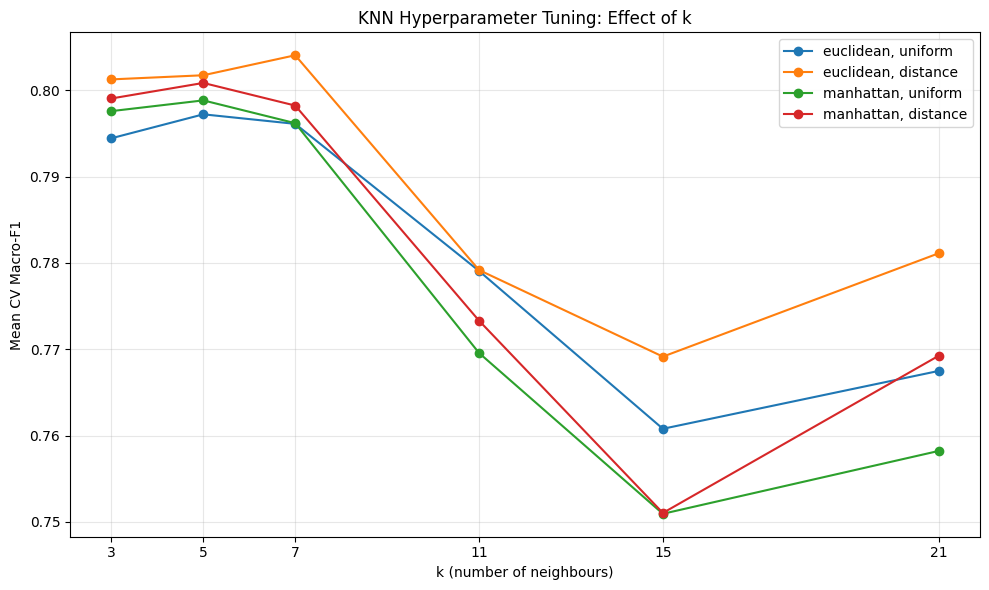

In [ ]:
plt.figure(figsize=(10, 6))

for metric in metrics:
    for weights in weight_schemes:
        f1s = [r["mean_f1"] for r in results
               if r["metric"] == metric and r["weights"] == weights]
        # results are sorted, so we need to extract in k order
        f1s_ordered = []
        for k in k_values:
            match = [r for r in results
                     if r["k"] == k and r["metric"] == metric
                     and r["weights"] == weights]
            f1s_ordered.append(match[0]["mean_f1"])
        plt.plot(k_values, f1s_ordered,
                 marker='o', label=f"{metric}, {weights}")

plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Macro-F1")
plt.title("KNN Hyperparameter Tuning: Effect of k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Tuning hyperparameters for softmax regression model

In [ ]:
# Tuning L2 regularization strength C=1/λ and convergence tolerance
DUMMY_TEXT_COL = "__dummy_text__"

df_train[DUMMY_TEXT_COL] = "placeholdertoken"
df_test[DUMMY_TEXT_COL] = "placeholdertoken"


param_grid_C = [0.1, 1, 10]
param_grid_tol = [1e-3, 1e-4, 1e-5]

results = []

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for C in param_grid_C:
    for tol in param_grid_tol:
        cv_scores = []

        for fold, (inner_train_idx, val_idx) in enumerate(
            sgkf.split(df_train, y_train, groups_train)
        ):
            fold_train_df = df_train.iloc[inner_train_idx].copy()
            fold_val_df = df_train.iloc[val_idx].copy()

            y_fold_train = y_train[inner_train_idx]
            y_fold_val = y_train[val_idx]

            # same preprocessing, but NO text features for softmax
            X_fold_train, fold_fit_params = build_feature_matrix(
                fold_train_df,
                NUM_COLS,
                LIKERT_COLS,
                CAT_COLS,
                [DUMMY_TEXT_COL],
                fit_params=None,
                verbose=False
            )

            X_fold_val, _ = build_feature_matrix(
                fold_val_df,
                NUM_COLS,
                LIKERT_COLS,
                CAT_COLS,
                [DUMMY_TEXT_COL],
                fit_params=fold_fit_params,
                verbose=False
            )

            model = LogisticRegression(
                solver="lbfgs",
                C=C,
                tol=tol,
                max_iter=2000
            )

            model.fit(X_fold_train, y_fold_train)
            y_fold_val_pred = model.predict(X_fold_val)

            fold_f1 = f1_score(y_fold_val, y_fold_val_pred, average="macro")
            cv_scores.append(fold_f1)

        mean_score = np.mean(cv_scores)
        results.append((C, tol, mean_score))
        print(f"C={C}, tol={tol}, mean macro-F1={mean_score:.4f}")

best_C, best_tol, best_cv_score = max(results, key=lambda x: x[2])

print("\nBest hyperparameters:")
print("C =", best_C)
print("tol =", best_tol)
print("Best mean CV macro-F1 =", best_cv_score)

C=0.1, tol=0.001, mean macro-F1=0.8363
C=0.1, tol=0.0001, mean macro-F1=0.8362
C=0.1, tol=1e-05, mean macro-F1=0.8362
C=1, tol=0.001, mean macro-F1=0.8343
C=1, tol=0.0001, mean macro-F1=0.8366
C=1, tol=1e-05, mean macro-F1=0.8359
C=10, tol=0.001, mean macro-F1=0.8344
C=10, tol=0.0001, mean macro-F1=0.8365
C=10, tol=1e-05, mean macro-F1=0.8365

Best hyperparameters:
C = 1
tol = 0.0001
Best mean CV macro-F1 = 0.8365701832288991


### Tuning hyperparameters for MLP model


In [15]:

# ==============================
# Hyperparameter grid（已移除 dropout）
# ==============================

param_grid = {
    "hidden_layers": [(32,), (64,), (128,), (64, 32), (128, 64)],
    "learning_rate_init": [0.01, 0.001],
    "alpha": [0.0001, 0.001, 0.01],
    "activation": ["relu", "tanh"],
    "batch_size": [32, 64],
}

# ==============================
# 固定 epochs
# ==============================

FIXED_EPOCHS = 20

# ==============================
# CV setup
# ==============================

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results = []

# ==============================
# Grid search
# ==============================

for (hidden_layers,
     lr,
     alpha,
     activation,
     batch_size) in itertools.product(
        param_grid["hidden_layers"],
        param_grid["learning_rate_init"],
        param_grid["alpha"],
        param_grid["activation"],
        param_grid["batch_size"]
):

    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(df_train, y_train, groups_train)
    ):
        fold_train_df = df_train.iloc[train_idx].copy()
        fold_val_df = df_train.iloc[val_idx].copy()

        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        # ==============================
        # Feature preprocessing
        # ==============================

        X_fold_train, fit_params = build_feature_matrix(
            fold_train_df,
            NUM_COLS,
            LIKERT_COLS,
            CAT_COLS,
            TEXT_COLS,
            fit_params=None,
            verbose=False
        )

        X_fold_val, _ = build_feature_matrix(
            fold_val_df,
            NUM_COLS,
            LIKERT_COLS,
            CAT_COLS,
            TEXT_COLS,
            fit_params=fit_params,
            verbose=False
        )

        # ==============================
        # Model（固定 epochs + early stopping）
        # ==============================

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=lr,
            alpha=alpha,
            batch_size=batch_size,
            max_iter=FIXED_EPOCHS,

            # Early stopping
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            tol=1e-4,

            random_state=42
        )

        model.fit(X_fold_train, y_fold_train)

        y_pred = model.predict(X_fold_val)

        score = f1_score(y_fold_val, y_pred, average="macro")
        cv_scores.append(score)

    mean_score = np.mean(cv_scores)

    # ==============================
    # 保存结果
    # ==============================

    results.append({
        "hidden_layers": hidden_layers,
        "lr": lr,
        "alpha": alpha,
        "activation": activation,
        "batch_size": batch_size,
        "cv_macro_f1": mean_score
    })

    # ==============================
    # 干净输出（每个组合一行）
    # ==============================

    print(
        f"layers={hidden_layers}, lr={lr}, alpha={alpha}, "
        f"activation={activation}, batch={batch_size} "
        f"→ macro-F1={mean_score:.4f}"
    )

# ==============================
# 排序输出（推荐）
# ==============================

results_sorted = sorted(results, key=lambda x: x["cv_macro_f1"], reverse=True)

print("\nTop 10 configs:")
for r in results_sorted[:10]:
    print(
        f"layers={r['hidden_layers']}, lr={r['lr']}, alpha={r['alpha']} "
        f"→ F1={r['cv_macro_f1']:.4f}"
    )

# ==============================
# Best result
# ==============================

best_result = results_sorted[0]

print("\nBest config:")
print(best_result)

layers=(32,), lr=0.01, alpha=0.0001, activation=relu, batch=32 → macro-F1=0.8866
layers=(32,), lr=0.01, alpha=0.0001, activation=relu, batch=64 → macro-F1=0.8807
layers=(32,), lr=0.01, alpha=0.0001, activation=tanh, batch=32 → macro-F1=0.8640
layers=(32,), lr=0.01, alpha=0.0001, activation=tanh, batch=64 → macro-F1=0.8732
layers=(32,), lr=0.01, alpha=0.001, activation=relu, batch=32 → macro-F1=0.8854
layers=(32,), lr=0.01, alpha=0.001, activation=relu, batch=64 → macro-F1=0.8808
layers=(32,), lr=0.01, alpha=0.001, activation=tanh, batch=32 → macro-F1=0.8647
layers=(32,), lr=0.01, alpha=0.001, activation=tanh, batch=64 → macro-F1=0.8724
layers=(32,), lr=0.01, alpha=0.01, activation=relu, batch=32 → macro-F1=0.8806
layers=(32,), lr=0.01, alpha=0.01, activation=relu, batch=64 → macro-F1=0.8802
layers=(32,), lr=0.01, alpha=0.01, activation=tanh, batch=32 → macro-F1=0.8669
layers=(32,), lr=0.01, alpha=0.01, activation=tanh, batch=64 → macro-F1=0.8731
layers=(32,), lr=0.001, alpha=0.0001, ac

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


layers=(32,), lr=0.001, alpha=0.0001, activation=relu, batch=64 → macro-F1=0.8682
layers=(32,), lr=0.001, alpha=0.0001, activation=tanh, batch=32 → macro-F1=0.8638
layers=(32,), lr=0.001, alpha=0.0001, activation=tanh, batch=64 → macro-F1=0.8639
layers=(32,), lr=0.001, alpha=0.001, activation=relu, batch=32 → macro-F1=0.8742


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


layers=(32,), lr=0.001, alpha=0.001, activation=relu, batch=64 → macro-F1=0.8675
layers=(32,), lr=0.001, alpha=0.001, activation=tanh, batch=32 → macro-F1=0.8638
layers=(32,), lr=0.001, alpha=0.001, activation=tanh, batch=64 → macro-F1=0.8639
layers=(32,), lr=0.001, alpha=0.01, activation=relu, batch=32 → macro-F1=0.8736


...

layers=(128, 64), lr=0.01, alpha=0.01, activation=relu, batch=64 → macro-F1=0.8852
layers=(128, 64), lr=0.01, alpha=0.01, activation=tanh, batch=32 → macro-F1=0.8678
layers=(128, 64), lr=0.01, alpha=0.01, activation=tanh, batch=64 → macro-F1=0.8722


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


layers=(128, 64), lr=0.001, alpha=0.0001, activation=relu, batch=32 → macro-F1=0.8915
layers=(128, 64), lr=0.001, alpha=0.0001, activation=relu, batch=64 → macro-F1=0.8891
layers=(128, 64), lr=0.001, alpha=0.0001, activation=tanh, batch=32 → macro-F1=0.8819
layers=(128, 64), lr=0.001, alpha=0.0001, activation=tanh, batch=64 → macro-F1=0.8732


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


layers=(128, 64), lr=0.001, alpha=0.001, activation=relu, batch=32 → macro-F1=0.8900
layers=(128, 64), lr=0.001, alpha=0.001, activation=relu, batch=64 → macro-F1=0.8891
layers=(128, 64), lr=0.001, alpha=0.001, activation=tanh, batch=32 → macro-F1=0.8819
layers=(128, 64), lr=0.001, alpha=0.001, activation=tanh, batch=64 → macro-F1=0.8732
layers=(128, 64), lr=0.001, alpha=0.01, activation=relu, batch=32 → macro-F1=0.8902
layers=(128, 64), lr=0.001, alpha=0.01, activation=relu, batch=64 → macro-F1=0.8847
layers=(128, 64), lr=0.001, alpha=0.01, activation=tanh, batch=32 → macro-F1=0.8820
layers=(128, 64), lr=0.001, alpha=0.01, activation=tanh, batch=64 → macro-F1=0.8716

Top 10 configs:
layers=(128, 64), lr=0.001, alpha=0.0001 → F1=0.8915
layers=(128, 64), lr=0.001, alpha=0.01 → F1=0.8902
layers=(128, 64), lr=0.001, alpha=0.001 → F1=0.8900
layers=(128, 64), lr=0.001, alpha=0.0001 → F1=0.8891
layers=(128, 64), lr=0.001, alpha=0.001 → F1=0.8891
layers=(32,), lr=0.01, alpha=0.0001 → F1=0.886

## 5. Final Evaluation on Held-Out Test Set

We retrain the best configuration on the full training set and evaluate once on the held-out test set.

###KNN performance

In [ ]:
final_knn = KNeighborsClassifier(
    n_neighbors=best["k"], metric=best["metric"], weights=best["weights"]
)
final_knn.fit(X_train, y_train)
y_test_pred = final_knn.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average="macro")

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro-F1:  {test_f1:.4f}")
print(f"\nPer-class metrics:")
print(classification_report(y_test, y_test_pred,
                            target_names=list(LABEL_MAP.keys())))

Test Accuracy:  0.8378
Test Macro-F1:  0.8347

Per-class metrics:
                           precision    recall  f1-score   support

The Persistence of Memory       0.79      0.95      0.86       113
         The Starry Night       0.87      0.69      0.77       113
      The Water Lily Pond       0.88      0.88      0.88       113

                 accuracy                           0.84       339
                macro avg       0.84      0.84      0.83       339
             weighted avg       0.84      0.84      0.83       339



###Softmax regression performance

In [ ]:
X_train_softmax, softmax_fit_params = build_feature_matrix(
    df_train,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    [DUMMY_TEXT_COL],
    fit_params=None,
    verbose=False
)

X_test_softmax, _ = build_feature_matrix(
    df_test,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    [DUMMY_TEXT_COL],
    fit_params=softmax_fit_params,
    verbose=False
)

final_softmax = LogisticRegression(
    solver="lbfgs",
    C=best_C,
    tol=best_tol,
    max_iter=2000
)

final_softmax.fit(X_train_softmax, y_train)
y_test_pred = final_softmax.predict(X_test_softmax)

test_acc = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro-F1:  {test_macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=[INT_TO_LABEL[i] for i in range(3)]))

Test Accuracy:  0.8584
Test Macro-F1:  0.8585

Classification report:
                           precision    recall  f1-score   support

The Persistence of Memory       0.92      0.88      0.90       113
         The Starry Night       0.80      0.80      0.80       113
      The Water Lily Pond       0.86      0.89      0.88       113

                 accuracy                           0.86       339
                macro avg       0.86      0.86      0.86       339
             weighted avg       0.86      0.86      0.86       339



### MLP performance

In [17]:
# ==============================
# Step 1: 找到 best result
# ==============================

best_result = max(results, key=lambda x: x["cv_macro_f1"])

print("Best config:")
print(best_result)

# ==============================
# Step 2: 提取 best hyperparameters
# ==============================

best_hidden_layers = best_result["hidden_layers"]
best_activation = best_result["activation"]
best_lr = best_result["lr"]
best_alpha = best_result["alpha"]
best_batch_size = best_result["batch_size"]

# ==============================
# 固定 epochs（统一设置）
# ==============================

FIXED_EPOCHS = 20

# ==============================
# Step 3: Build feature matrix
# ==============================

X_train_mlp, mlp_fit_params = build_feature_matrix(
    df_train,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    TEXT_COLS,
    fit_params=None,
    verbose=False
)

X_test_mlp, _ = build_feature_matrix(
    df_test,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    TEXT_COLS,
    fit_params=mlp_fit_params,
    verbose=False
)

# ==============================
# Step 4: Final MLP model
# ==============================

final_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation=best_activation,
    learning_rate_init=best_lr,
    alpha=best_alpha,
    batch_size=best_batch_size,
    max_iter=FIXED_EPOCHS,   # ✅ 改这里

    # Early stopping（建议保持一致）
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    tol=1e-4,

    random_state=42
)

# ==============================
# Step 5: Train
# ==============================

final_mlp.fit(X_train_mlp, y_train)

# ==============================
# Step 6: Predict
# ==============================

y_test_pred = final_mlp.predict(X_test_mlp)

# ==============================
# Step 7: Evaluation
# ==============================

test_acc = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

print(f"\nTest Accuracy:  {test_acc:.4f}")
print(f"Test Macro-F1:  {test_macro_f1:.4f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[INT_TO_LABEL[i] for i in range(3)]
))

Best config:
{'hidden_layers': (128, 64), 'lr': 0.001, 'alpha': 0.0001, 'activation': 'relu', 'batch_size': 32, 'cv_macro_f1': np.float64(0.891545389585267)}

Test Accuracy:  0.8938
Test Macro-F1:  0.8933

Classification report:
                           precision    recall  f1-score   support

The Persistence of Memory       0.93      0.92      0.92       113
         The Starry Night       0.86      0.82      0.84       113
      The Water Lily Pond       0.89      0.94      0.91       113

                 accuracy                           0.89       339
                macro avg       0.89      0.89      0.89       339
             weighted avg       0.89      0.89      0.89       339



### Confusion Matrix

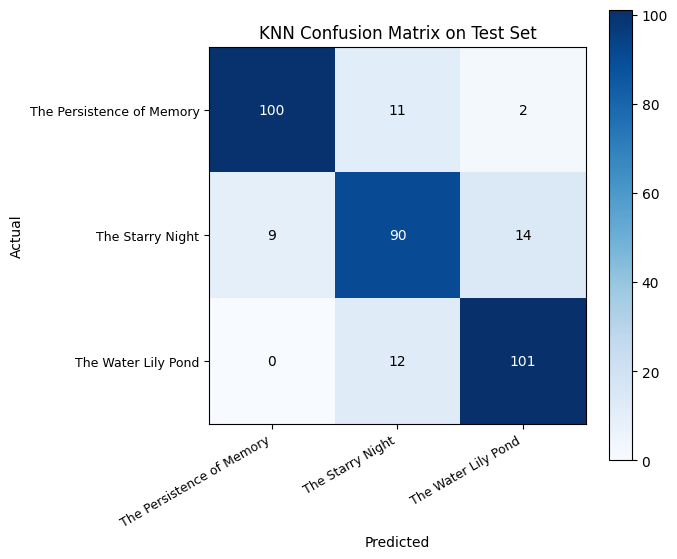

Saved knn_confusion_matrix.png


In [ ]:
labels = list(LABEL_MAP.keys())
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

# Annotate cells with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("KNN Confusion Matrix on Test Set")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved knn_confusion_matrix.png")

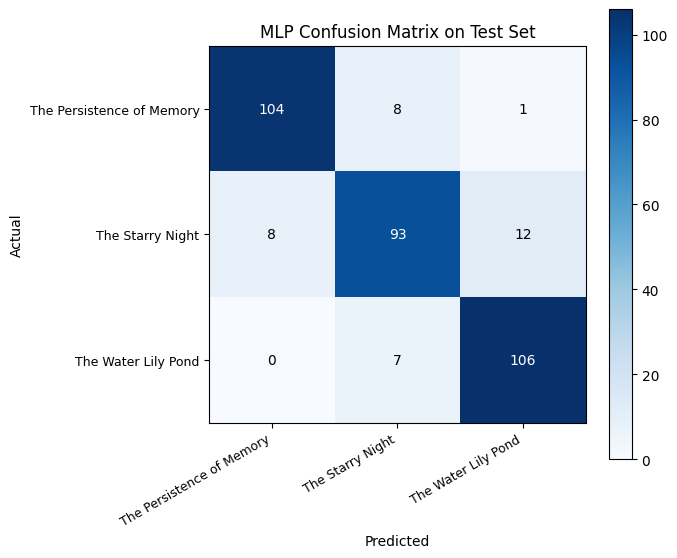

Saved mlp_confusion_matrix.png


In [19]:

# ==============================
# Confusion Matrix
# ==============================

labels = list(LABEL_MAP.keys())
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

# ==============================
# Annotate cells
# ==============================

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", color=color)

# ==============================
# Axis settings
# ==============================

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# ==============================
# Title（改成 MLP）
# ==============================

ax.set_title("MLP Confusion Matrix on Test Set")

# ==============================
# Color bar
# ==============================

fig.colorbar(im, ax=ax)

plt.tight_layout()

# ==============================
# Save figure（改名字）
# ==============================

plt.savefig("mlp_confusion_matrix.png", dpi=150, bbox_inches="tight")

plt.show()

print("Saved mlp_confusion_matrix.png")

## 6. Save Artifacts

KNN needs the entire training set at inference time, so we save the preprocessed features, labels, and all preprocessing parameters.

In [ ]:
np.save("knn_X_train.npy", X_train)
np.save("knn_y_train.npy", y_train)

save_params = {
    "best_hyperparams": {
        "k": int(best["k"]),
        "metric": best["metric"],
        "weights": best["weights"]
    },
    "label_map": {str(v): k for k, v in LABEL_MAP.items()},
    "preprocessing": {
        "numeric": fit_params["numeric"],
        "categorical": fit_params["categorical"],
        "text": fit_params["text"]["vocab_idf"]
    },
    "num_cols": NUM_COLS,
    "likert_cols": LIKERT_COLS,
    "cat_cols": CAT_COLS,
    "text_cols": TEXT_COLS,
    "pay_col": PAY_COL,
    "epsilon": epsilon
}

with open("knn_params.json", "w") as f:
    json.dump(save_params, f, indent=2)

import os
for fname in ["knn_X_train.npy", "knn_y_train.npy", "knn_params.json"]:
    print(f"{fname}: {os.path.getsize(fname) / 1024:.1f} KB")

knn_X_train.npy: 1810.2 KB
knn_y_train.npy: 10.6 KB
knn_params.json: 11.3 KB


save MLP paramaters

In [20]:
import pickle

model_data = {
    "weights": final_mlp.coefs_,
    "biases": final_mlp.intercepts_,
    "fit_params": mlp_fit_params
}

with open("mlp_model.pkl", "wb") as f:
    pickle.dump(model_data, f)